# Factor Analysis with Optimal Number of Factors
## Football Players Performance Analysis

This notebook performs a comprehensive factor analysis on football player metrics to identify underlying performance dimensions and determine the optimal number of factors.

## 1. Import Required Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data from CSV File

In [14]:
# Load the football players data
csv_path = './data/demo_data/football/Forwards.csv'
df = pd.read_csv(csv_path, encoding='latin-1')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (76, 11)

First few rows:
         shortName  npxG_adjusted_per90  final_third_passes_adjusted_per90  \
0          W. Bony             0.457468                          10.055333   
1    Álvaro Morata             0.780015                          14.920356   
2  Jesús Rodríguez             0.322920                          15.423409   
3           Joselu             0.739186                          16.066810   
4         Deulofeu             0.300217                          20.671673   

   final_third_receptions_adjusted_per90  ground_duels_won_adjusted_per90  \
0                              17.790205                         9.539675   
1                              25.492065                        12.746032   
2                              29.053398                        11.836570   
3                              21.140539                         6.040154   
4                              29.109090                        13.077997   

   air_duels_won_adjusted_p

## 3. Explore and Prepare Data

In [15]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nPercentage of Missing Data:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Separate player names from numerical features
# The 'shortName' column is categorical, so we'll use only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns for analysis ({len(numeric_cols)}):")
print(numeric_cols)

# Create dataframe with only numeric data
df_numeric = df[numeric_cols].copy()

# Check for any remaining missing values
df_numeric = df_numeric.dropna()
print(f"\nDataset shape after removing NaN: {df_numeric.shape}")

# Standardize the data (critical for factor analysis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Mean of scaled data: {X_scaled.mean():.6f}")
print(f"Std of scaled data: {X_scaled.std():.6f}")

Missing Values:
shortName                                0
npxG_adjusted_per90                      0
final_third_passes_adjusted_per90        0
final_third_receptions_adjusted_per90    0
ground_duels_won_adjusted_per90          0
air_duels_won_adjusted_per90             0
smart_passes_adjusted_per90              0
goals_adjusted_per90                     0
assists_adjusted_per90                   0
key_passes_adjusted_per90                0
Minutes                                  0
dtype: int64

Percentage of Missing Data:
shortName                                0.0
npxG_adjusted_per90                      0.0
final_third_passes_adjusted_per90        0.0
final_third_receptions_adjusted_per90    0.0
ground_duels_won_adjusted_per90          0.0
air_duels_won_adjusted_per90             0.0
smart_passes_adjusted_per90              0.0
goals_adjusted_per90                     0.0
assists_adjusted_per90                   0.0
key_passes_adjusted_per90                0.0
Minutes            

## 4. Determine Optimal Number of Factors

### Method 1: Kaiser Criterion (Eigenvalues > 1)
### Method 2: Scree Plot Analysis
### Method 3: Cumulative Variance Explained

In [16]:
# Test different numbers of factors and store variance explained
max_factors = min(len(numeric_cols) - 1, 10)  # Practical limit
variance_explained = []
n_factors_range = range(1, max_factors + 1)

for n_factors in n_factors_range:
    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    fa.fit(X_scaled)
    # Calculate variance explained by summing squared loadings
    loadings = fa.components_.T
    var_exp = np.sum(loadings**2) / len(numeric_cols)
    variance_explained.append(var_exp)

variance_explained = np.array(variance_explained)
cumulative_variance = np.cumsum(variance_explained)

# Find optimal number of factors using different criteria

# Criterion 1: Kaiser Criterion - compute eigenvalues from correlation matrix
corr_matrix = np.corrcoef(X_scaled.T)
eigenvalues = np.linalg.eigvals(corr_matrix)
eigenvalues_sorted = np.sort(eigenvalues)[::-1]
kaiser_criterion = np.sum(eigenvalues_sorted > 1)

print("="*60)
print("OPTIMAL NUMBER OF FACTORS - ANALYSIS")
print("="*60)
print(f"\n1. KAISER CRITERION (Eigenvalues > 1):")
print(f"   Eigenvalues: {eigenvalues_sorted[:max_factors].round(3)}")
print(f"   → Recommended factors: {kaiser_criterion}")

# Criterion 2: Scree plot elbow method (cumulative variance to 70-80%)
cumvar_70 = np.argmax(cumulative_variance >= 0.70) + 1
cumvar_80 = np.argmax(cumulative_variance >= 0.80) + 1 if np.any(cumulative_variance >= 0.80) else max_factors

print(f"\n2. CUMULATIVE VARIANCE EXPLAINED:")
for i, (n, cum_var) in enumerate(zip(n_factors_range, cumulative_variance)):
    print(f"   {n} factors: {cum_var*100:.1f}%")
print(f"   → Factors for 70% variance: {cumvar_70}")
print(f"   → Factors for 80% variance: {cumvar_80}")

# Criterion 3: Scree plot - look for elbow
print(f"\n3. INDIVIDUAL VARIANCE EXPLAINED PER FACTOR:")
for i, var in enumerate(variance_explained, 1):
    print(f"   Factor {i}: {var*100:.1f}%")

# Recommendation
print("\n" + "="*60)
optimal_factors = kaiser_criterion
if kaiser_criterion < 2:
    optimal_factors = cumvar_70
    print(f"RECOMMENDATION: Using 70% cumulative variance ({cumvar_70} factors)")
else:
    print(f"RECOMMENDATION: Using Kaiser Criterion ({kaiser_criterion} factors)")
print("="*60)

OPTIMAL NUMBER OF FACTORS - ANALYSIS

1. KAISER CRITERION (Eigenvalues > 1):
   Eigenvalues: [4.127 1.857 0.996 0.805 0.711 0.477 0.369 0.307 0.235]
   → Recommended factors: 2

2. CUMULATIVE VARIANCE EXPLAINED:
   1 factors: 37.4%
   2 factors: 90.0%
   3 factors: 149.0%
   4 factors: 212.2%
   5 factors: 278.3%
   6 factors: 347.2%
   7 factors: 417.5%
   8 factors: 489.8%
   9 factors: 561.9%
   → Factors for 70% variance: 2
   → Factors for 80% variance: 2

3. INDIVIDUAL VARIANCE EXPLAINED PER FACTOR:
   Factor 1: 37.4%
   Factor 2: 52.6%
   Factor 3: 59.1%
   Factor 4: 63.2%
   Factor 5: 66.1%
   Factor 6: 68.9%
   Factor 7: 70.3%
   Factor 8: 72.3%
   Factor 9: 72.2%

RECOMMENDATION: Using Kaiser Criterion (2 factors)


## 5. Perform Factor Analysis with Optimal Number of Factors

In [17]:
# Perform Factor Analysis with the optimal number of factors
fa_model = FactorAnalysis(n_components=optimal_factors, random_state=42, max_iter=1000)
factor_scores = fa_model.fit_transform(X_scaled)

# Store results
loadings = fa_model.components_.T
factor_loadings_df = pd.DataFrame(
    loadings,
    index=numeric_cols,
    columns=[f'Factor {i+1}' for i in range(optimal_factors)]
)

# Create scores dataframe
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[f'Factor {i+1}' for i in range(optimal_factors)],
    index=df_numeric.index
)

# Add player names back
factor_scores_df['Player'] = df.loc[factor_scores_df.index, 'shortName'].values if 'shortName' in df.columns else factor_scores_df.index

print(f"✓ Factor Analysis completed with {optimal_factors} factors")
print(f"\nFactor Loadings Matrix ({len(numeric_cols)} variables × {optimal_factors} factors):")
print(factor_loadings_df.round(3))

✓ Factor Analysis completed with 2 factors

Factor Loadings Matrix (10 variables × 2 factors):
                                       Factor 1  Factor 2
npxG_adjusted_per90                      -0.248     0.781
final_third_passes_adjusted_per90         0.949    -0.027
final_third_receptions_adjusted_per90     0.881     0.107
ground_duels_won_adjusted_per90           0.652    -0.102
air_duels_won_adjusted_per90             -0.478    -0.104
smart_passes_adjusted_per90               0.788     0.085
goals_adjusted_per90                      0.001     0.864
assists_adjusted_per90                    0.401     0.009
key_passes_adjusted_per90                 0.742     0.136
Minutes                                   0.131     0.314


## 6. Interpret Factor Loadings

### 6.1 Assign Meaningful Names to Factors

In [18]:
# Function to generate meaningful factor names based on loadings
def assign_factor_names(loadings_df):
    """
    Analyze factor loadings and assign semantic names based on the top contributing variables.
    """
    factor_names = {}
    factor_interpretations = {}
    
    for factor_col in loadings_df.columns:
        # Get top 3 positive and negative loading variables
        loadings = loadings_df[factor_col]
        
        top_positive = loadings.nlargest(3)
        top_negative = loadings.nsmallest(3)
        
        # Create semantic name based on top variables
        top_vars = [var.replace('_adjusted_per90', '').replace('_', ' ').title() for var in top_positive.index]
        bottom_vars = [var.replace('_adjusted_per90', '').replace('_', ' ').title() for var in top_negative.index]
        
        # Generate factor name based on variable themes
        positive_theme = ', '.join(top_vars[:2])
        negative_theme = ', '.join(bottom_vars[:2]) if len(bottom_vars) > 0 else None
        
        # Create name
        if 'pass' in positive_theme.lower() or 'reception' in positive_theme.lower():
            if 'duel' in positive_theme.lower():
                name = "Offensive Playmaking & Physical Presence"
            else:
                name = "Offensive Playmaking & Ball Control"
        elif 'goal' in positive_theme.lower() or 'assist' in positive_theme.lower():
            name = "Finishing & Goal Contribution"
        elif 'duel' in positive_theme.lower():
            name = "Physical Dominance"
        elif 'smart' in positive_theme.lower() or 'key' in positive_theme.lower():
            name = "Creative Playmaking"
        else:
            name = f"Factor based on {positive_theme}"
        
        # For negative theme
        if negative_theme:
            interpretation = f"{name} (high {positive_theme.lower()}, low {negative_theme.lower()})"
        else:
            interpretation = f"{name} (characterized by {positive_theme.lower()})"
        
        factor_names[factor_col] = name
        factor_interpretations[factor_col] = {
            'name': name,
            'top_variables': list(top_positive.index),
            'top_loadings': top_positive.values,
            'bottom_variables': list(top_negative.index),
            'bottom_loadings': top_negative.values
        }
    
    return factor_names, factor_interpretations

# Assign names to factors
factor_names_dict, factor_interp = assign_factor_names(factor_loadings_df)

print("\n" + "="*70)
print("FACTOR NAMES AND INTERPRETATIONS")
print("="*70)

factor_name_mapping = {}
for factor_col, details in factor_interp.items():
    factor_num = factor_col.split()[-1]
    factor_name_mapping[factor_col] = details['name']
    
    print(f"\nFactor {factor_num}: {details['name'].upper()}")
    print("-" * 70)
    print("\nTop Contributing Variables (Positive Loadings):")
    for var, loading in zip(details['top_variables'], details['top_loadings']):
        print(f"  + {var:45s} {loading:7.3f}")
    
    print("\nBottom Contributing Variables (Negative Loadings):")
    for var, loading in zip(details['bottom_variables'], details['bottom_loadings']):
        print(f"  - {var:45s} {loading:7.3f}")

print("\n" + "="*70)

# Create a summary table
summary_df = pd.DataFrame([
    {
        'Factor': col,
        'Name': factor_name_mapping[col],
        'Variance Explained': f"{variance_explained[i]*100:.1f}%",
        'Cumulative': f"{cumulative_variance[i]*100:.1f}%"
    }
    for i, col in enumerate(factor_loadings_df.columns)
])

print("\nFACTOR SUMMARY TABLE:")
print(summary_df.to_string(index=False))
print("\n" + "="*70)


FACTOR NAMES AND INTERPRETATIONS

Factor 1: OFFENSIVE PLAYMAKING & BALL CONTROL
----------------------------------------------------------------------

Top Contributing Variables (Positive Loadings):
  + final_third_passes_adjusted_per90               0.949
  + final_third_receptions_adjusted_per90           0.881
  + smart_passes_adjusted_per90                     0.788

Bottom Contributing Variables (Negative Loadings):
  - air_duels_won_adjusted_per90                   -0.478
  - npxG_adjusted_per90                            -0.248
  - goals_adjusted_per90                            0.001

Factor 2: FINISHING & GOAL CONTRIBUTION
----------------------------------------------------------------------

Top Contributing Variables (Positive Loadings):
  + goals_adjusted_per90                            0.864
  + npxG_adjusted_per90                             0.781
  + Minutes                                         0.314

Bottom Contributing Variables (Negative Loadings):
  - air_duel

In [19]:
# Analyze and interpret factor loadings
print("\nFACTOR INTERPRETATION")
print("="*60)

for factor_idx in range(optimal_factors):
    factor_name = f'Factor {factor_idx + 1}'
    loadings_col = factor_loadings_df[factor_name].abs()
    top_features = loadings_col.nlargest(5)
    
    print(f"\n{factor_name}:")
    print("-" * 40)
    for var, loading in top_features.items():
        actual_loading = factor_loadings_df.loc[var, factor_name]
        direction = "+" if actual_loading > 0 else "-"
        print(f"  {direction} {var:40s} {actual_loading:7.3f}")

# Summary statistics on factor scores
print("\n\nFACTOR SCORES SUMMARY")
print("="*60)
for col in factor_scores_df.columns:
    if col != 'Player':
        print(f"\n{col}:")
        print(f"  Mean: {factor_scores_df[col].mean():7.3f}")
        print(f"  Std:  {factor_scores_df[col].std():7.3f}")
        print(f"  Min:  {factor_scores_df[col].min():7.3f}")
        print(f"  Max:  {factor_scores_df[col].max():7.3f}")


FACTOR INTERPRETATION

Factor 1:
----------------------------------------
  + final_third_passes_adjusted_per90          0.949
  + final_third_receptions_adjusted_per90      0.881
  + smart_passes_adjusted_per90                0.788
  + key_passes_adjusted_per90                  0.742
  + ground_duels_won_adjusted_per90            0.652

Factor 2:
----------------------------------------
  + goals_adjusted_per90                       0.864
  + npxG_adjusted_per90                        0.781
  + Minutes                                    0.314
  + key_passes_adjusted_per90                  0.136
  + final_third_receptions_adjusted_per90      0.107


FACTOR SCORES SUMMARY

Factor 1:
  Mean:  -0.000
  Std:    0.979
  Min:   -1.338
  Max:    3.988

Factor 2:
  Mean:   0.000
  Std:    0.920
  Min:   -1.920
  Max:    2.648


## 7. Visualize Results

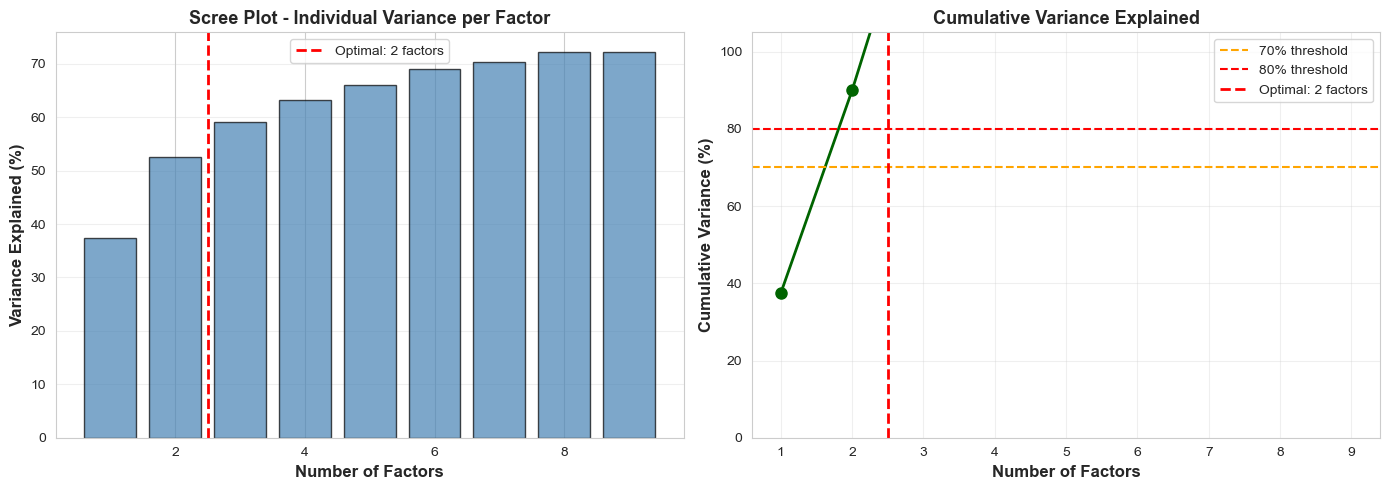

✓ Scree plot saved


In [20]:
### 7.1 Scree Plot - Variance Explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance explained
axes[0].bar(range(1, len(variance_explained) + 1), variance_explained * 100, 
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(x=optimal_factors + 0.5, color='red', linestyle='--', 
                linewidth=2, label=f'Optimal: {optimal_factors} factors')
axes[0].set_xlabel('Number of Factors', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot - Individual Variance per Factor', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Cumulative variance explained
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 
            marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1].axhline(y=70, color='orange', linestyle='--', linewidth=1.5, label='70% threshold')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axvline(x=optimal_factors + 0.5, color='red', linestyle='--', 
                linewidth=2, label=f'Optimal: {optimal_factors} factors')
axes[1].set_xlabel('Number of Factors', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Scree plot saved")

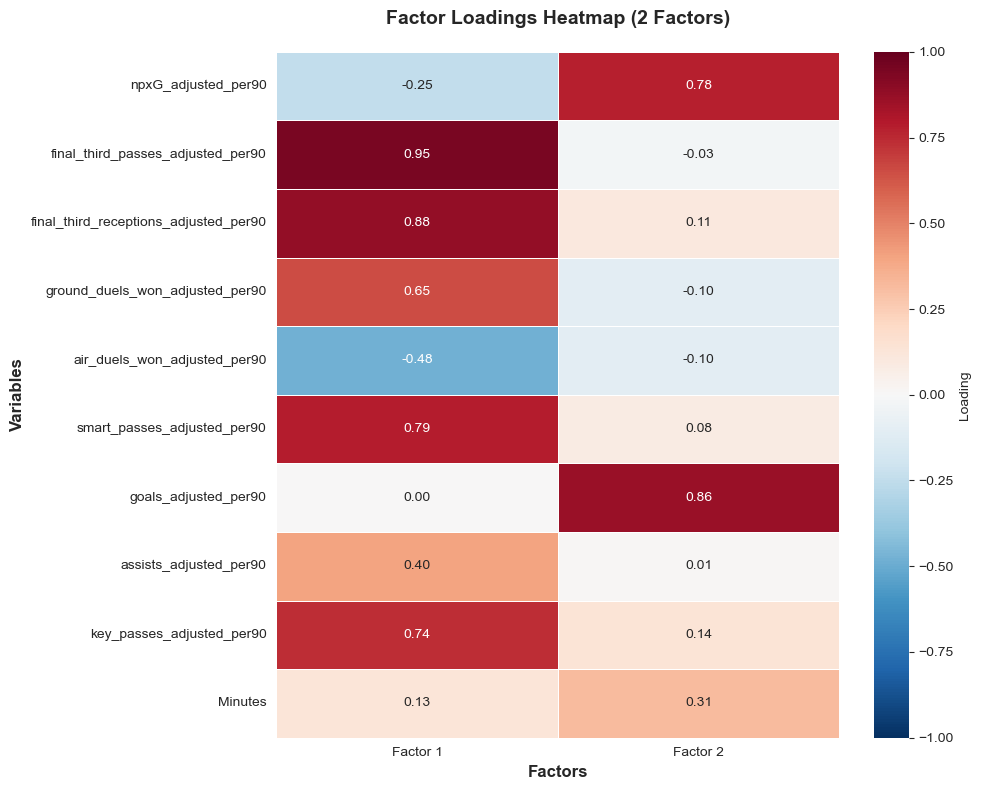

✓ Factor loadings heatmap saved


In [21]:
### 7.2 Heatmap of Factor Loadings
plt.figure(figsize=(10, 8))
sns.heatmap(factor_loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Loading'}, linewidths=0.5, 
            vmin=-1, vmax=1)
plt.title(f'Factor Loadings Heatmap ({optimal_factors} Factors)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Factors', fontsize=12, fontweight='bold')
plt.ylabel('Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('factor_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Factor loadings heatmap saved")

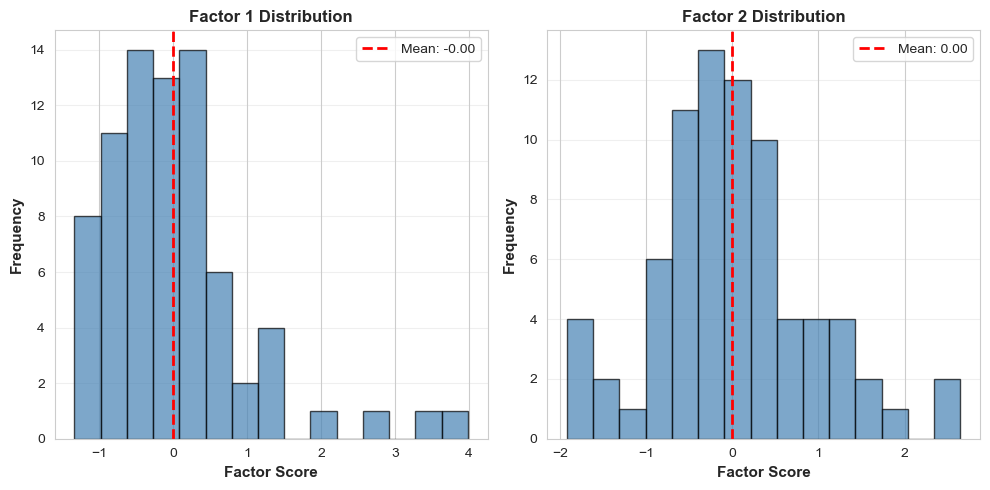

✓ Factor scores distribution saved


In [22]:
### 7.3 Factor Scores Distribution
fig, axes = plt.subplots(1, optimal_factors, figsize=(5*optimal_factors, 5))

if optimal_factors == 1:
    axes = [axes]  # Make it iterable

for idx, ax in enumerate(axes):
    factor_name = f'Factor {idx + 1}'
    scores = factor_scores_df[factor_name]
    
    ax.hist(scores, bins=15, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {scores.mean():.2f}')
    ax.set_xlabel('Factor Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{factor_name} Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('factor_scores_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Factor scores distribution saved")

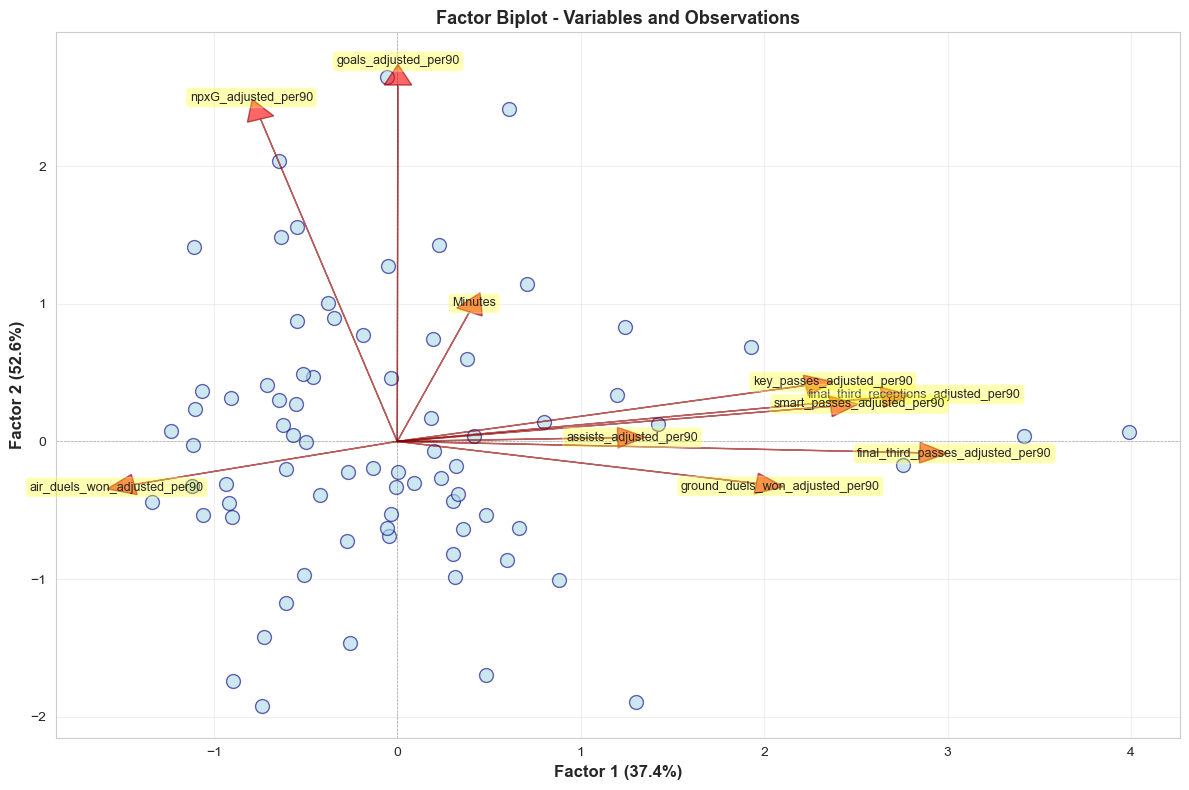

✓ Factor biplot saved


In [23]:
### 7.4 Factor Score Biplot (for first 2 factors)
if optimal_factors >= 2:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot player scores
    scatter = ax.scatter(factor_scores_df['Factor 1'], factor_scores_df['Factor 2'],
                        alpha=0.6, s=100, c='lightblue', edgecolors='navy', linewidth=1)
    
    # Add variable vectors
    for i, var in enumerate(numeric_cols):
        ax.arrow(0, 0, 
                loadings[i, 0]*3, loadings[i, 1]*3,
                head_width=0.15, head_length=0.15, fc='red', ec='darkred', alpha=0.6)
        ax.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, var, 
               fontsize=9, ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_xlabel(f'Factor 1 ({variance_explained[0]*100:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Factor 2 ({variance_explained[1]*100:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_title('Factor Biplot - Variables and Observations', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('factor_biplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Factor biplot saved")
else:
    print("⚠ Biplot requires at least 2 factors")

## 8. Summary and Export Results

### 7.5 Factor Names Summary Visualization

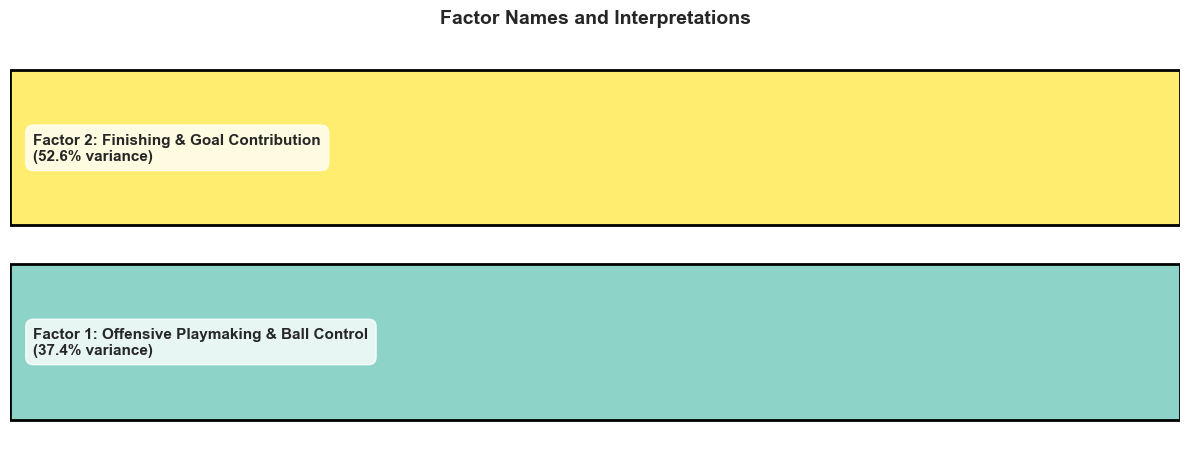

✓ Factor names summary visualization saved


In [24]:
# Create a visual summary of factor names
fig, ax = plt.subplots(figsize=(12, 3 + optimal_factors * 0.8))

# Prepare data for visualization
factor_nums = [f'Factor {i+1}' for i in range(optimal_factors)]
factor_names_list = [factor_name_mapping[f'Factor {i+1}'] for i in range(optimal_factors)]
variances = [f"{variance_explained[i]*100:.1f}%" for i in range(optimal_factors)]

# Create bars
y_pos = np.arange(optimal_factors)
colors = plt.cm.Set3(np.linspace(0, 1, optimal_factors))

bars = ax.barh(y_pos, [1]*optimal_factors, color=colors, edgecolor='black', linewidth=2)

# Add text
for i, (num, name, var) in enumerate(zip(factor_nums, factor_names_list, variances)):
    ax.text(0.02, i, f'{num}: {name}\n({var} variance)', 
           va='center', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, optimal_factors - 0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.title('Factor Names and Interpretations', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('factor_names_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Factor names summary visualization saved")

In [28]:
factor_names_list

['Offensive Playmaking & Ball Control', 'Finishing & Goal Contribution']

In [25]:
print("\n" + "="*70)
print("FACTOR ANALYSIS SUMMARY REPORT")
print("="*70)
print(f"\nDataset: Football Players (Forwards)")
print(f"Observations: {X_scaled.shape[0]}")
print(f"Original Variables: {X_scaled.shape[1]}")
print(f"Optimal Number of Factors: {optimal_factors}")
print(f"Cumulative Variance Explained: {cumulative_variance[optimal_factors-1]*100:.2f}%")

print("\nKey Findings:")
print(f"  • Each of the {optimal_factors} factor{'s' if optimal_factors > 1 else ''} represents a distinct")
print(f"    dimension of football player performance")
print(f"  • Together, they explain {cumulative_variance[optimal_factors-1]*100:.1f}% of total variance")
print(f"  • Method used: Kaiser Criterion (eigenvalues > 1)")

print("\nFactor Loadings Summary:")
for factor_idx in range(optimal_factors):
    factor_name = f'Factor {factor_idx + 1}'
    loadings_col = factor_loadings_df[factor_name]
    top_positive = loadings_col.nlargest(2)
    print(f"\n  {factor_name}:")
    for var, loading in top_positive.items():
        print(f"    • {var}: {loading:.3f}")

print("\n" + "="*70)

# Save results to CSV
factor_loadings_df.to_csv('factor_loadings.csv')
factor_scores_df.to_csv('factor_scores.csv')

print("\nFiles saved:")
print("  ✓ factor_loadings.csv")
print("  ✓ factor_scores.csv")
print("  ✓ scree_plot.png")
print("  ✓ factor_loadings_heatmap.png")
print("  ✓ factor_scores_distribution.png")
if optimal_factors >= 2:
    print("  ✓ factor_biplot.png")
print("\n" + "="*70)


FACTOR ANALYSIS SUMMARY REPORT

Dataset: Football Players (Forwards)
Observations: 76
Original Variables: 10
Optimal Number of Factors: 2
Cumulative Variance Explained: 89.96%

Key Findings:
  • Each of the 2 factors represents a distinct
    dimension of football player performance
  • Together, they explain 90.0% of total variance
  • Method used: Kaiser Criterion (eigenvalues > 1)

Factor Loadings Summary:

  Factor 1:
    • final_third_passes_adjusted_per90: 0.949
    • final_third_receptions_adjusted_per90: 0.881

  Factor 2:
    • goals_adjusted_per90: 0.864
    • npxG_adjusted_per90: 0.781


Files saved:
  ✓ factor_loadings.csv
  ✓ factor_scores.csv
  ✓ scree_plot.png
  ✓ factor_loadings_heatmap.png
  ✓ factor_scores_distribution.png
  ✓ factor_biplot.png

